# Bivariate Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path

# Find project root and set working directory
current = Path.cwd()
while current.name != "credit_fraud_ml":
    current = current.parent
os.chdir(current)
sys.path.append(str(current))

from src.data.data_loader import DataLoader

loader = DataLoader()
data = loader.load_all('train')
transactions = data['transactions']
customers = data['customers']
terminals = data['terminals']

✓ Loaded 291,231 train transactions
✓ Loaded 1,000 customers
✓ Loaded 2,000 terminals


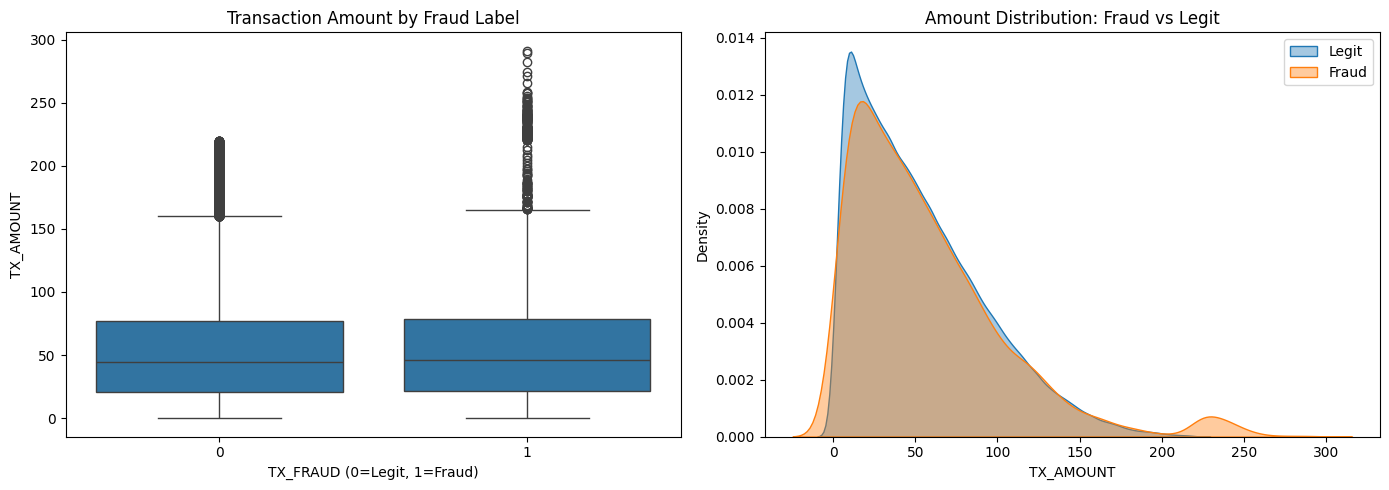

             count       mean        std   min     25%     50%    75%     max
TX_FRAUD                                                                     
0         284649.0  53.090356  39.358071  0.00  21.120  44.750  76.79  219.95
1           6582.0  57.157419  47.801818  0.05  21.335  45.875  78.93  291.15


In [2]:
# ── 1. TX_AMOUNT vs Fraud ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='TX_FRAUD', y='TX_AMOUNT', data=transactions, ax=axes[0])
axes[0].set_title('Transaction Amount by Fraud Label')
axes[0].set_xlabel('TX_FRAUD (0=Legit, 1=Fraud)')
axes[0].set_ylabel('TX_AMOUNT')

for label, grp in transactions.groupby('TX_FRAUD'):
    sns.kdeplot(grp['TX_AMOUNT'], ax=axes[1], label='Fraud' if label else 'Legit', fill=True, alpha=0.4)
axes[1].set_title('Amount Distribution: Fraud vs Legit')
axes[1].set_xlabel('TX_AMOUNT')
axes[1].legend()

plt.tight_layout()
plt.show()

print(transactions.groupby('TX_FRAUD')['TX_AMOUNT'].describe())

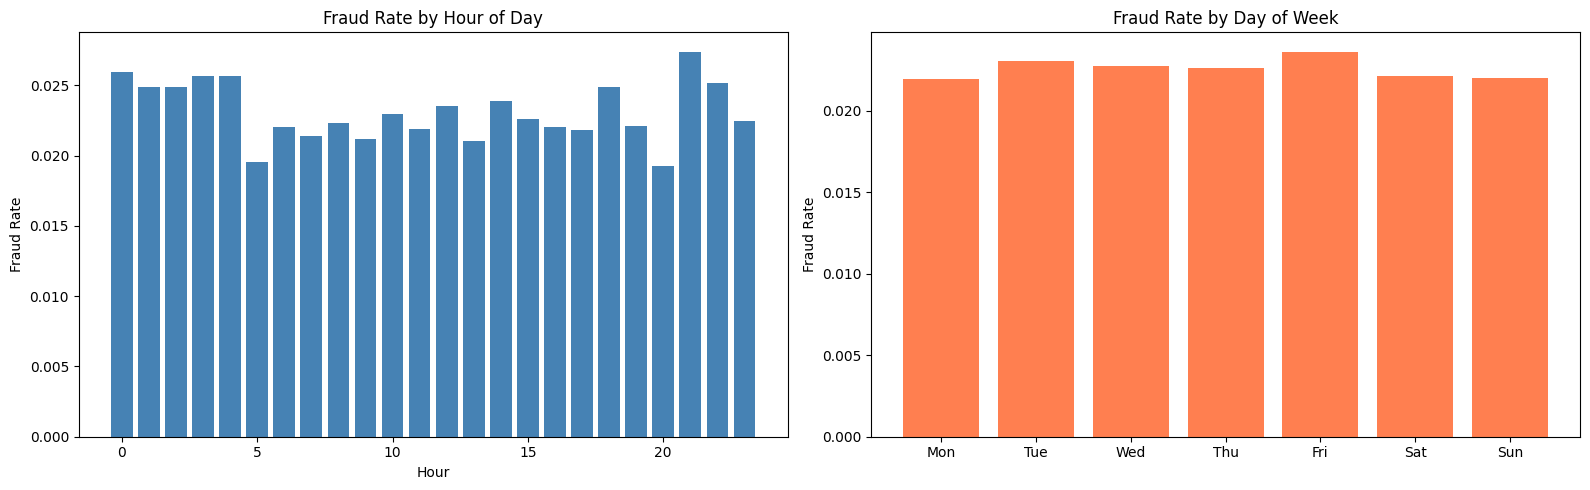

In [3]:
# ── 2. Fraud Rate by Hour of Day ───────────────────────────────────────────
transactions['TX_HOUR'] = transactions['TX_DATETIME'].dt.hour
transactions['TX_DAY'] = transactions['TX_DATETIME'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fraud_by_hour = transactions.groupby('TX_HOUR')['TX_FRAUD'].mean()
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color='steelblue')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Rate')

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fraud_by_day = transactions.groupby('TX_DAY')['TX_FRAUD'].mean()
axes[1].bar(fraud_by_day.index, fraud_by_day.values, color='coral')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

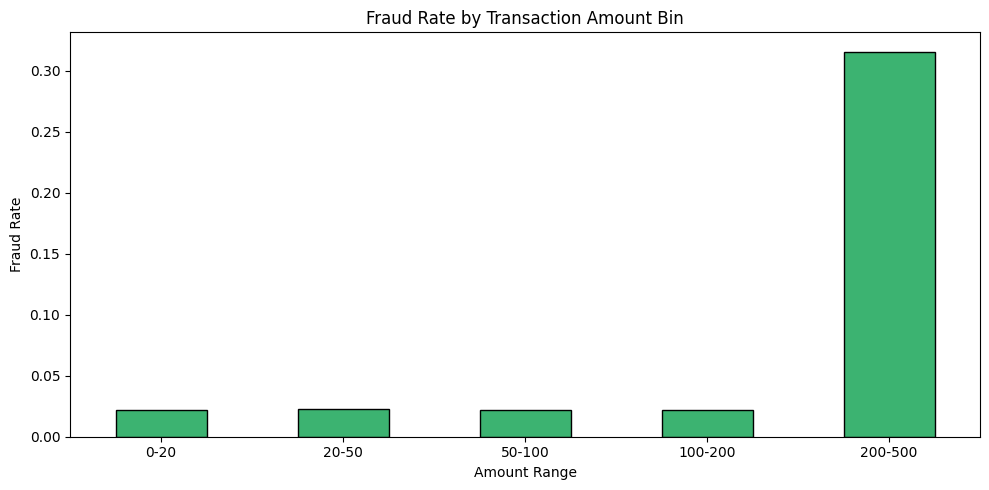

AMOUNT_BIN
0-20       0.0222
20-50      0.0225
50-100     0.0217
100-200    0.0218
200-500    0.3158
Name: TX_FRAUD, dtype: float64


In [4]:
# ── 3. Fraud Rate by Amount Bins ───────────────────────────────────────────
transactions['AMOUNT_BIN'] = pd.cut(
    transactions['TX_AMOUNT'],
    bins=[0, 20, 50, 100, 200, 500, 5000],
    labels=['0-20', '20-50', '50-100', '100-200', '200-500', '500+']
)

fraud_by_bin = transactions.groupby('AMOUNT_BIN', observed=True)['TX_FRAUD'].mean()

plt.figure(figsize=(10, 5))
fraud_by_bin.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Fraud Rate by Transaction Amount Bin')
plt.xlabel('Amount Range')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(fraud_by_bin.round(4))

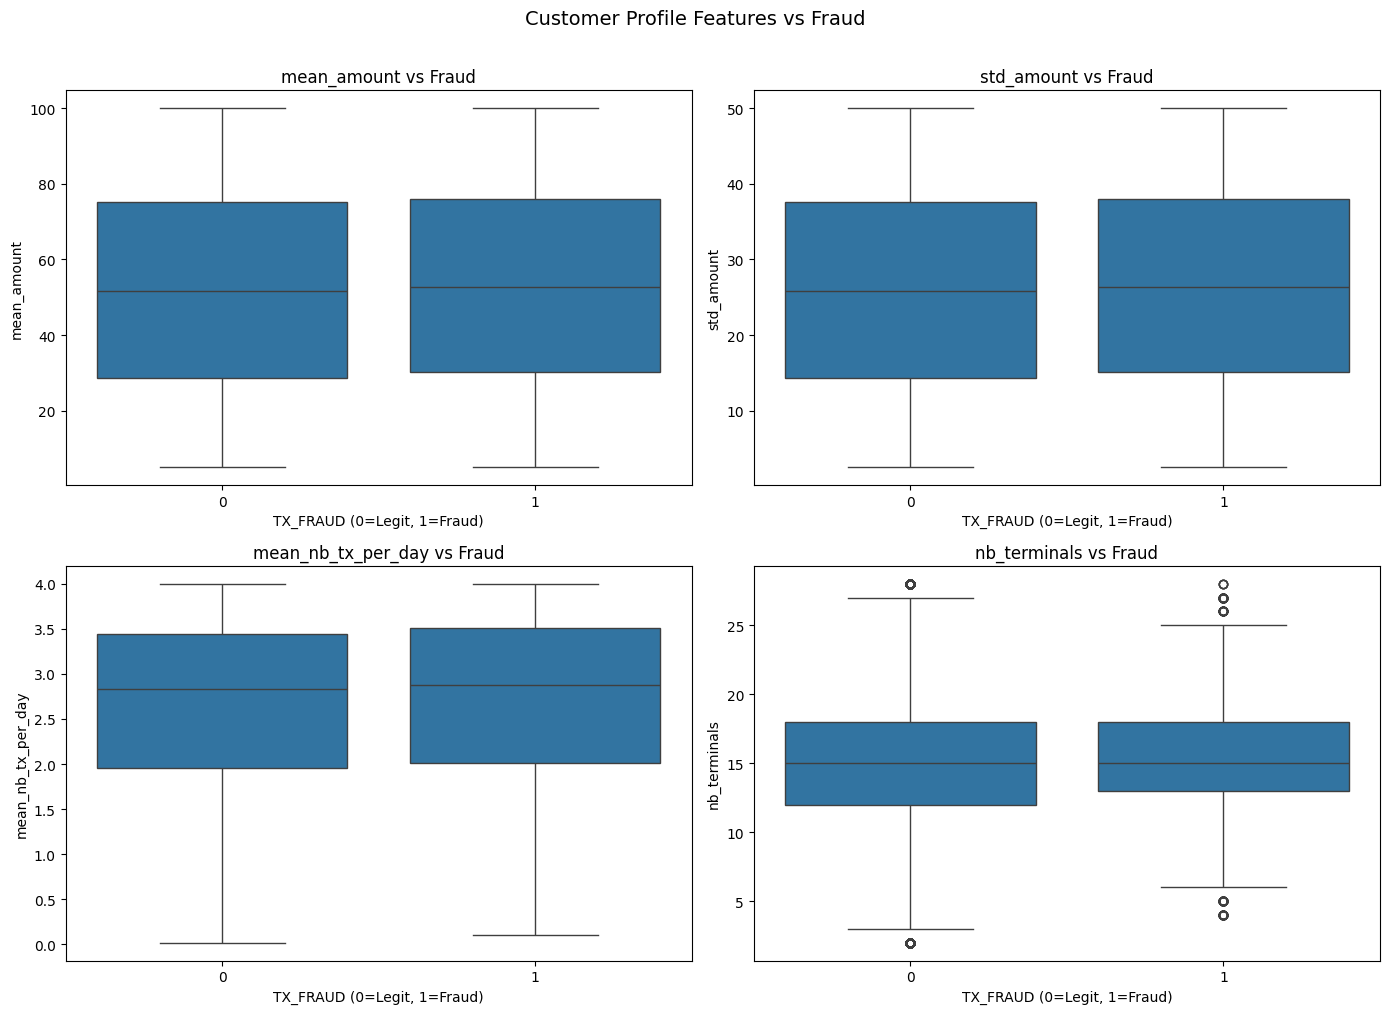

In [5]:
# ── 4. Customer Features vs Fraud ──────────────────────────────────────────
merged = transactions.merge(customers, on='CUSTOMER_ID', how='left')

customer_features = ['mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.flatten(), customer_features):
    sns.boxplot(x='TX_FRAUD', y=feat, data=merged, ax=ax)
    ax.set_title(f'{feat} vs Fraud')
    ax.set_xlabel('TX_FRAUD (0=Legit, 1=Fraud)')

plt.suptitle('Customer Profile Features vs Fraud', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/xx/hwc5qmd970gc45gm2hg43vj40000gn/T/ipykernel_63635/3427853006.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=terminal_stats, x='TERMINAL_ID', y='fraud_rate', palette='Reds_r')


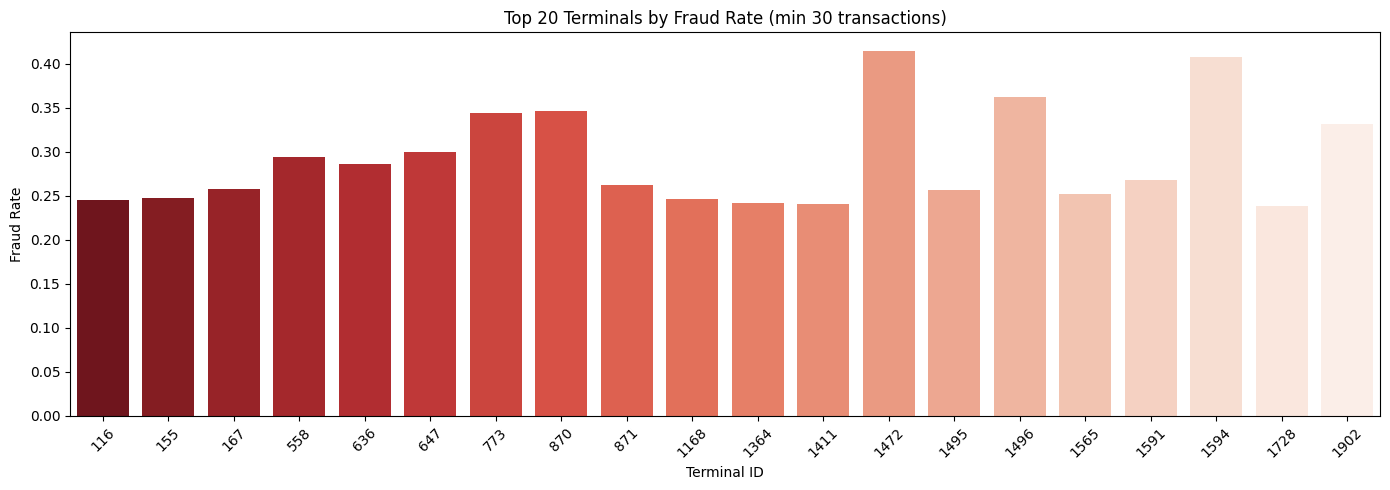

 TERMINAL_ID  fraud_rate  tx_count
        1472    0.414894        94
        1594    0.407821       179
        1496    0.362245       196
         870    0.346774       124
         773    0.343590       195
        1902    0.331551       187
         647    0.300000        30
         558    0.294118        51
         636    0.285714        70
        1591    0.267606        71


In [6]:
# ── 5. Top Terminals by Fraud Rate ─────────────────────────────────────────
terminal_stats = (
    transactions.groupby('TERMINAL_ID')['TX_FRAUD']
    .agg(fraud_rate='mean', tx_count='count')
    .query('tx_count >= 30')
    .sort_values('fraud_rate', ascending=False)
    .head(20)
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.barplot(data=terminal_stats, x='TERMINAL_ID', y='fraud_rate', palette='Reds_r')
plt.title('Top 20 Terminals by Fraud Rate (min 30 transactions)')
plt.xlabel('Terminal ID')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(terminal_stats[['TERMINAL_ID', 'fraud_rate', 'tx_count']].head(10).to_string(index=False))

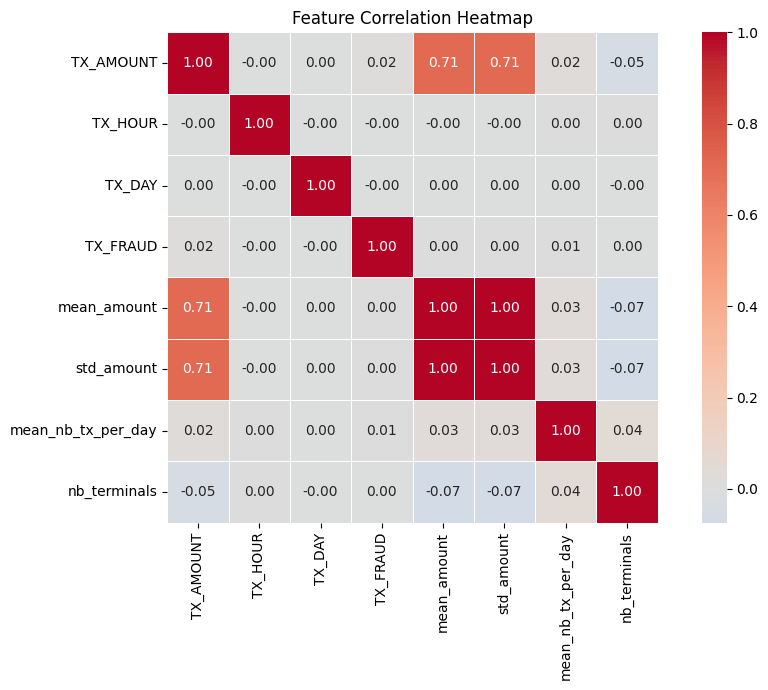

In [7]:
# ── 6. Correlation Heatmap (merged features) ───────────────────────────────
corr_cols = ['TX_AMOUNT', 'TX_HOUR', 'TX_DAY', 'TX_FRAUD',
             'mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals']

corr_matrix = merged[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()